In [32]:
from neo4j import GraphDatabase
import json, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import defaultdict


In [33]:

URI = "neo4j+s://8246cfe2.databases.neo4j.io"
AUTH = ("8246cfe2", "bER1MV-oLUpbZexNqP19OxGzt-5ePVuLRAhJ5n8q1eg")

driver = GraphDatabase.driver(URI, auth=AUTH)

# Verify connection
with driver.session() as session:
    result = session.run("RETURN 1 AS ping")
    print("Connected:", result.single()["ping"] == 1)

Connected: True


In [3]:
import json

with open('postgres_public_task0_final_output.json', 'r') as f:
    raw_data = json.load(f)

print(f"Total records: {len(raw_data)}")

# Filter to 2,000 usable students (skip 10,000 null-major rows)
students = [
    r for r in raw_data
    if r.get('major') is not None
    and r.get('academic_bucket') is not None
    and r.get('skill_bucket') is not None
    and r.get('experience_bucket') is not None
]
print(f"Usable students: {len(students)}")

#Clear graph 
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("Graph cleared.")


with driver.session() as session:
    session.run("""
        CREATE CONSTRAINT IF NOT EXISTS
        FOR (s:Student) REQUIRE s.student_key IS UNIQUE
    """)

#Load query
LOAD_QUERY = """
MERGE (s:Student {student_key: $student_key})
SET s.major                   = $major,
    s.academic_score          = $academic_score,
    s.skill_score             = $skill_score,
    s.experience_score        = $experience_score,
    s.placed                  = $placed,
    s.academic_bucket         = $academic_bucket,
    s.skill_bucket            = $skill_bucket,
    s.experience_bucket       = $experience_bucket,
    s.most_important_category = $most_important_category

MERGE (m:Major {name: $major})
MERGE (ab:AcademicBucket   {level: $academic_bucket})
MERGE (sb:SkillBucket      {level: $skill_bucket})
MERGE (eb:ExperienceBucket {level: $experience_bucket})
MERGE (o:Outcome {status: CASE WHEN $placed = 1 THEN 'Placed' ELSE 'NotPlaced' END})

MERGE (s)-[:BELONGS_TO]->(m)
MERGE (s)-[:HAS_ACADEMIC_BUCKET]->(ab)
MERGE (s)-[:HAS_SKILL_BUCKET]->(sb)
MERGE (s)-[:HAS_EXPERIENCE_BUCKET]->(eb)
MERGE (s)-[:HAS_OUTCOME]->(o)
"""

# Load all students 
with driver.session() as session:
    for i, s in enumerate(students):
        session.run(LOAD_QUERY,
            student_key             = s['student_key'],
            major                   = s['major'],
            academic_score          = float(s.get('academic_score') or 0),
            skill_score             = float(s.get('skill_score') or 0),
            experience_score        = float(s.get('experience_score') or 0),
            placed                  = int(s.get('placed') or 0),
            academic_bucket         = s['academic_bucket'],
            skill_bucket            = s['skill_bucket'],
            experience_bucket       = s['experience_bucket'],
            most_important_category = s.get('most_important_category') or '',
        )
        if (i + 1) % 500 == 0:
            print(f"  Loaded {i+1}/{len(students)} students...")

print(f"All {len(students)} students loaded.")

#Set Major lift properties
major_lifts = {}
for s in students:
    m = s['major']
    if m not in major_lifts and s.get('academic_lift') is not None:
        major_lifts[m] = {
            'academic_lift':           s['academic_lift'],
            'skill_lift':              s['skill_lift'],
            'experience_lift':         s['experience_lift'],
            'most_important_category': s.get('most_important_category') or '',
        }

with driver.session() as session:
    for major, lifts in major_lifts.items():
        session.run("""
            MATCH (m:Major {name: $major})
            SET m.academic_lift           = $academic_lift,
                m.skill_lift              = $skill_lift,
                m.experience_lift         = $experience_lift,
                m.most_important_category = $most_important_category
        """, major=major, **lifts)

print(f"Lift properties set for {len(major_lifts)} majors.")


with driver.session() as session:
    nodes = session.run("MATCH (n) RETURN count(n) AS c").single()['c']
    edges = session.run("MATCH ()-[r]->() RETURN count(r) AS c").single()['c']
    print(f"Graph built: {nodes} nodes | {edges} edges | {len(students)} students")




Total records: 12922
Usable students: 2000
Graph cleared.
  Loaded 500/2000 students...
  Loaded 1000/2000 students...
  Loaded 1500/2000 students...
  Loaded 2000/2000 students...
All 2000 students loaded.
Lift properties set for 6 majors.
Graph built: 2015 nodes | 10000 edges | 2000 students


In [5]:
#create similar edges
import json
from collections import defaultdict

with open('postgres_public_task0_final_output.json', 'r') as f:
    raw = json.load(f)

students_data = [r for r in raw
                 if r.get('major') is not None
                 and r.get('academic_bucket') is not None
                 and r.get('skill_bucket') is not None
                 and r.get('experience_bucket') is not None]

major_groups = defaultdict(list)
for s in students_data:
    major_groups[s['major']].append(s)

all_pairs = []
for major, group in major_groups.items():
    print(f"Computing pairs for {major} ({len(group)} students)...")
    for i in range(len(group)):
        for j in range(i+1, len(group)):
            a, b = group[i], group[j]
            shared = sum([
                a['academic_bucket']   == b['academic_bucket'],
                a['skill_bucket']      == b['skill_bucket'],
                a['experience_bucket'] == b['experience_bucket'],
            ])
            if shared >= 2:
                all_pairs.append({
                    'key_a':  a['student_key'],
                    'key_b':  b['student_key'],
                    'shared': shared
                })

print(f"\nTotal pairs found: {len(all_pairs)}")

#limit under Aura's 400,000 limit
all_pairs = all_pairs[:190000]
print(f"Writing {len(all_pairs)} pairs (capped to stay under Aura limit)...")

# Write in batches of 200
BATCH_SIZE = 200
for i in range(0, len(all_pairs), BATCH_SIZE):
    batch = all_pairs[i:i + BATCH_SIZE]
    driver.execute_query("""
        UNWIND $pairs AS pair
        MATCH (a:Student {student_key: pair.key_a})
        MATCH (b:Student {student_key: pair.key_b})
        MERGE (a)-[:SIMILAR_TO {shared_buckets: pair.shared}]->(b)
        MERGE (b)-[:SIMILAR_TO {shared_buckets: pair.shared}]->(a)
    """, pairs=batch)
    if (i // BATCH_SIZE + 1) % 50 == 0:
        done = min(i + BATCH_SIZE, len(all_pairs))
        print(f"  Written {done}/{len(all_pairs)} pairs...")

# Final count
total = driver.execute_query(
    "MATCH ()-[r:SIMILAR_TO]->() RETURN count(r) AS c"
).records[0]['c']
print(f"\n SIMILAR_TO edges created: {total}")

Computing pairs for CSE (691 students)...
Computing pairs for Civil (219 students)...
Computing pairs for ECE (295 students)...
Computing pairs for EEE (201 students)...
Computing pairs for IT (381 students)...
Computing pairs for Mechanical (213 students)...

Total pairs found: 296981
Writing 190000 pairs (capped to stay under Aura limit)...
  Written 10000/190000 pairs...
  Written 20000/190000 pairs...
  Written 30000/190000 pairs...
  Written 40000/190000 pairs...
  Written 50000/190000 pairs...
  Written 60000/190000 pairs...
  Written 70000/190000 pairs...
  Written 80000/190000 pairs...
  Written 90000/190000 pairs...
  Written 100000/190000 pairs...
  Written 110000/190000 pairs...
  Written 120000/190000 pairs...
  Written 130000/190000 pairs...
  Written 140000/190000 pairs...
  Written 150000/190000 pairs...
  Written 160000/190000 pairs...
  Written 170000/190000 pairs...
  Written 180000/190000 pairs...
  Written 190000/190000 pairs...

✅ SIMILAR_TO edges created: 380000



Centrality Analysis — CSE
  Category Bucket Level  Placed Students        Node Label
     Skill         High              404        Skill:High
  Academic         High              242     Academic:High
Experience         High              214   Experience:High
Experience       Medium              147 Experience:Medium
  Academic       Medium              147   Academic:Medium
Experience          Low               43    Experience:Low
  Academic          Low               15      Academic:Low


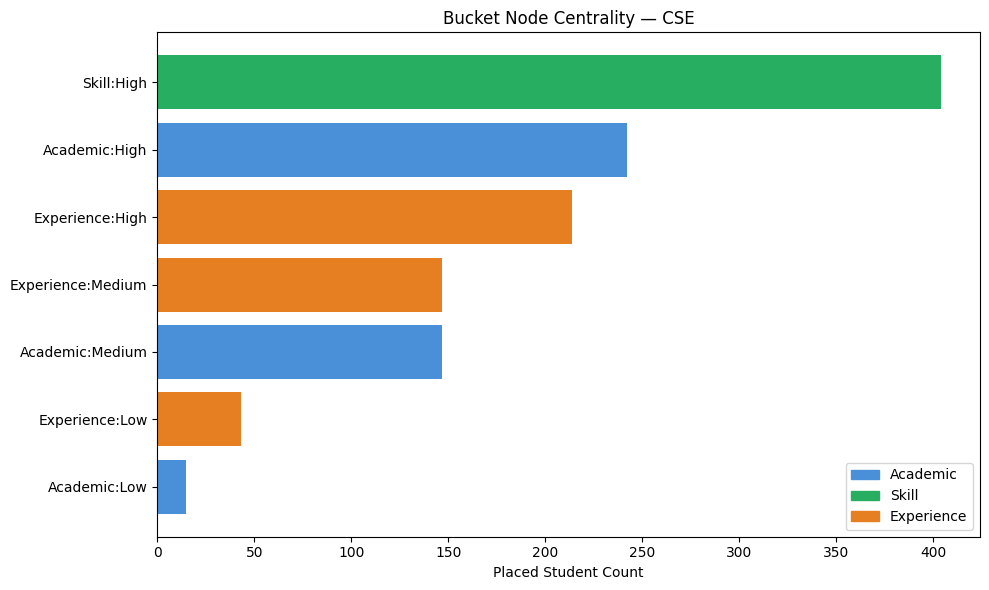

Saved: outputs/task5_centrality_CSE.png


In [34]:
import os
os.makedirs('outputs', exist_ok=True)

def centrality_analysis(major='CSE'):
    rows = []
    with driver.session() as session:
        for bucket_type, node_label, rel in [
            ('Academic',   'AcademicBucket',   'HAS_ACADEMIC_BUCKET'),
            ('Skill',      'SkillBucket',       'HAS_SKILL_BUCKET'),
            ('Experience', 'ExperienceBucket',  'HAS_EXPERIENCE_BUCKET'),
        ]:
            result = session.run(f"""
                MATCH (s:Student)-[:BELONGS_TO]->(m:Major {{name: $major}}),
                      (s)-[:{rel}]->(b:{node_label}),
                      (s)-[:HAS_OUTCOME]->(:Outcome {{status: 'Placed'}})
                RETURN b.level AS level, COUNT(s) AS placed_count
                ORDER BY placed_count DESC
            """, major=major)
            for rec in result:
                rows.append({
                    'Category':        bucket_type,
                    'Bucket Level':    rec['level'],
                    'Placed Students': rec['placed_count'],
                    'Node Label':      f"{bucket_type}:{rec['level']}"
                })

    df = pd.DataFrame(rows).sort_values('Placed Students', ascending=False)
    print(f"\nCentrality Analysis — {major}")
    print(df.to_string(index=False))

    colors     = {'Academic': '#4A90D9', 'Skill': '#27AE60', 'Experience': '#E67E22'}
    bar_colors = [colors[r['Category']] for _, r in df.iterrows()]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df['Node Label'], df['Placed Students'], color=bar_colors)
    ax.set_xlabel('Placed Student Count')
    ax.set_title(f'Bucket Node Centrality — {major}')
    ax.invert_yaxis()
    legend = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
    ax.legend(handles=legend)
    plt.tight_layout()
    plt.savefig(f'outputs/task5_centrality_{major}.png', dpi=150)
    plt.show()
    print(f"Saved: outputs/task5_centrality_{major}.png")

centrality_analysis('CSE')

In [35]:
def run_multihop_query(major='CSE'):
    with driver.session() as session:
        total_placed = session.run("""
            MATCH (s:Student)-[:BELONGS_TO]->(:Major {name: $major}),
                  (s)-[:HAS_OUTCOME]->(:Outcome {status: 'Placed'})
            RETURN COUNT(s) AS total
        """, major=major).single()['total']

        if total_placed == 0:
            print(f"\n{major}: No placed students — skipping.")
            return

        result = session.run("""
            MATCH (s:Student)-[:BELONGS_TO]->(:Major {name: $major}),
                  (s)-[:HAS_ACADEMIC_BUCKET]->(ab:AcademicBucket),
                  (s)-[:HAS_SKILL_BUCKET]->(sb:SkillBucket),
                  (s)-[:HAS_EXPERIENCE_BUCKET]->(eb:ExperienceBucket),
                  (s)-[:HAS_OUTCOME]->(:Outcome {status: 'Placed'})
            RETURN ab.level AS academic,
                   sb.level AS skill,
                   eb.level AS experience,
                   COUNT(s) AS placed_count,
                   ROUND(100.0 * COUNT(s) / $total_placed, 1) AS pct
            ORDER BY placed_count DESC
            LIMIT 10
        """, major=major, total_placed=total_placed)

        rows = [dict(r) for r in result]
        df   = pd.DataFrame(rows)
        print(f"\n=== TOP PLACEMENT PATHS: {major} (total placed: {total_placed}) ===")
        print(df.to_string(index=False))

for major in ['CSE', 'IT', 'ECE', 'Civil', 'Mechanical', 'EEE']:
    run_multihop_query(major)




=== TOP PLACEMENT PATHS: CSE (total placed: 404) ===
academic skill experience  placed_count  pct
    High  High       High           129 31.9
    High  High     Medium            86 21.3
  Medium  High       High            80 19.8
  Medium  High     Medium            54 13.4
    High  High        Low            27  6.7
  Medium  High        Low            13  3.2
     Low  High     Medium             7  1.7
     Low  High       High             5  1.2
     Low  High        Low             3  0.7

=== TOP PLACEMENT PATHS: IT (total placed: 196) ===
academic skill experience  placed_count  pct
    High  High       High            71 36.2
    High  High     Medium            49 25.0
  Medium  High       High            33 16.8
  Medium  High     Medium            19  9.7
    High  High        Low            14  7.1
  Medium  High        Low             6  3.1
     Low  High       High             2  1.0
     Low  High        Low             1  0.5
     Low  High     Medium             

In [36]:
def analyze_student(student_key: str):
    with driver.session() as session:

        #Fetch student profile
        profile = session.run("""
            MATCH (s:Student {student_key: $key})
            MATCH (s)-[:BELONGS_TO]->(m:Major)
            MATCH (s)-[:HAS_OUTCOME]->(o:Outcome)
            RETURN s.major               AS major,
                   s.academic_bucket     AS acad,
                   s.skill_bucket        AS skill,
                   s.experience_bucket   AS exp,
                   o.status              AS outcome,
                   m.academic_lift       AS al,
                   m.skill_lift          AS sl,
                   m.experience_lift     AS el,
                   m.most_important_category AS best_cat
        """, key=student_key).single()

        if not profile:
            print(f"Student {student_key} not found.")
            return

        major   = profile['major']
        acad    = profile['acad']
        skill   = profile['skill']
        exp     = profile['exp']
        outcome = profile['outcome']
        al      = profile['al'] or 0
        sl      = profile['sl'] or 0
        el      = profile['el'] or 0

        print(f"\n{'='*60}")
        print(f"  STUDENT: {student_key} | Major: {major} | Status: {outcome}")
        print(f"  Profile: Academic={acad} | Skill={skill} | Experience={exp}")
        print(f"{'='*60}")

        #Placed peer counts per bucket level
        peer_stats = {}
        for bucket_type, prop in [
            ('academic',   'academic_bucket'),
            ('skill',      'skill_bucket'),
            ('experience', 'experience_bucket'),
        ]:
            result = session.run(f"""
                MATCH (peer:Student)-[:BELONGS_TO]->(:Major {{name: $major}}),
                      (peer)-[:HAS_OUTCOME]->(:Outcome {{status: 'Placed'}})
                RETURN peer.{prop} AS level, COUNT(peer) AS cnt
            """, major=major)
            peer_stats[bucket_type] = {r['level']: r['cnt'] for r in result}

        total_placed    = sum(peer_stats['skill'].values()) or 1
        student_buckets = {'academic': acad, 'skill': skill, 'experience': exp}
        lift_map        = {'academic': al, 'skill': sl, 'experience': el}

        #Shortest path to placed peer
        paths = session.run("""
            MATCH path = shortestPath(
                (me:Student {student_key: $key})-[:SIMILAR_TO*..6]-(placed:Student)
            )
            WHERE placed.placed = 1 AND placed.student_key <> $key
            RETURN length(path) AS hops, placed.student_key AS peer
            ORDER BY hops ASC
            LIMIT 5
        """, key=student_key).data()

        #Peers reachable by upgrading each bucket
        upgrade_gains = {}
        for bucket_type, prop in [
            ('academic',   'academic_bucket'),
            ('skill',      'skill_bucket'),
            ('experience', 'experience_bucket'),
        ]:
            if student_buckets[bucket_type] != 'High':
                r = session.run(f"""
                    MATCH (peer:Student)-[:BELONGS_TO]->(:Major {{name: $major}}),
                          (peer)-[:HAS_OUTCOME]->(:Outcome {{status: 'Placed'}})
                    WHERE peer.{prop} = 'High'
                    RETURN COUNT(peer) AS cnt
                """, major=major).single()
                current = peer_stats[bucket_type].get(student_buckets[bucket_type], 0)
                upgrade_gains[bucket_type] = (r['cnt'] if r else 0) - current
            else:
                upgrade_gains[bucket_type] = 0

        
        print("\n LAYER 1 — GRAPH DISTANCE ANALYSIS:")
        print("-" * 50)
        if paths:
            nearest  = paths[0]
            same_hop = sum(1 for p in paths if p['hops'] == nearest['hops'])
            print(f"  You are {nearest['hops']} hop(s) from the nearest placed {major} peer.")
            print(f"  Nearest placed peer: {nearest['peer']}")
            print(f"  {same_hop} placed {major} students within {nearest['hops']} hop(s).")
        else:
            print("  No path found — SIMILAR_TO edges may not have loaded.")

        
        print("\n LAYER 2 — PEER EVIDENCE (from graph):")
        print("-" * 50)
        print(f"  Among {total_placed} placed {major} students:")
        for cat in ['skill', 'academic', 'experience']:
            high_count = peer_stats[cat].get('High', 0)
            pct        = round(100 * high_count / total_placed)
            status     = "✓ you have this" if student_buckets[cat] == 'High' else "← MISSING"
            print(f"  → {pct}% have {cat.capitalize()}:High  {status}")

        current_peers = session.run("""
            MATCH (peer:Student)-[:BELONGS_TO]->(:Major {name: $major}),
                  (peer)-[:HAS_OUTCOME]->(:Outcome {status: 'Placed'})
            WHERE peer.academic_bucket   = $ab
              AND peer.skill_bucket      = $sb
              AND peer.experience_bucket = $eb
            RETURN COUNT(peer) AS cnt
        """, major=major, ab=acad, sb=skill, eb=exp).single()['cnt']

        print(f"\n  {current_peers} placed peers share your exact profile")
        print(f"  (Acad:{acad}, Skill:{skill}, Exp:{exp}) = "
              f"{round(100*current_peers/total_placed)}% of placed {major}.")

       
        print("\n LAYER 3 — GRAPH RECOMMENDATION:")
        print("-" * 50)

        priorities = []
        for cat in ['academic', 'skill', 'experience']:
            if student_buckets[cat] == 'High':
                priorities.append((cat, -999, lift_map[cat], -999))
            else:
                raw_gain = upgrade_gains.get(cat, 0)
                lift = lift_map[cat]

                # if lift is negative, do not prioritize it
                effective_gain = raw_gain if lift >= 0 else -1

                priorities.append((cat, raw_gain, lift, effective_gain))

        priorities.sort(key=lambda x: x[3], reverse=True)

        for i, (cat, gain, lift, effective_gain) in enumerate(priorities, 1):
            label = cat.capitalize()
            print(f"\n  Priority {i} — {label.upper()} (lift: {lift:+.3f})")
            if gain == -999:
                print(f"    Already optimal — maintain {label}:High.")
            elif lift < -0.01:
                print(f"    Lift is NEGATIVE for {major} — do NOT prioritize {label}.")
            else:
                print(f"    Upgrading {label}: {student_buckets[cat]} → High")
                print(f"    connects you to +{gain} more placed {major} students.")
                
        candidates = [
            (c, upgrade_gains.get(c, 0), lift_map[c])
            for c in ['academic', 'skill', 'experience']
            if student_buckets[c] != 'High' and lift_map[c] >= 0
        ]

        best = max(candidates, key=lambda x: x[1], default=(None, 0, 0))
        
        print(f"\n  ── BOTTOM LINE ──────────────────────────────")
        if best[0]:
            print(f"  One change ({best[0].capitalize()}: "
                  f"{student_buckets[best[0]]} → High) connects you to "
                  f"+{best[1]} more placed peers in {major}.")
        else:
            print(f"  No positive-lift upgrade is recommended for this profile.")
        print()

# Demo calls
analyze_student('d3_100')   
analyze_student('d3_1005')  



  STUDENT: d3_100 | Major: CSE | Status: NotPlaced
  Profile: Academic=Medium | Skill=High | Experience=Medium

 LAYER 1 — GRAPH DISTANCE ANALYSIS:
--------------------------------------------------
  You are 1 hop(s) from the nearest placed CSE peer.
  Nearest placed peer: d3_1035
  5 placed CSE students within 1 hop(s).

 LAYER 2 — PEER EVIDENCE (from graph):
--------------------------------------------------
  Among 404 placed CSE students:
  → 100% have Skill:High  ✓ you have this
  → 60% have Academic:High  ← MISSING
  → 53% have Experience:High  ← MISSING

  54 placed peers share your exact profile
  (Acad:Medium, Skill:High, Exp:Medium) = 13% of placed CSE.

 LAYER 3 — GRAPH RECOMMENDATION:
--------------------------------------------------

  Priority 1 — EXPERIENCE (lift: +0.107)
    Upgrading Experience: Medium → High
    connects you to +67 more placed CSE students.

  Priority 2 — ACADEMIC (lift: -0.058)
    Lift is NEGATIVE for CSE — do NOT prioritize Academic.

  Priorit

In [37]:
def visualize_subgraph(student_key: str):
    os.makedirs('outputs', exist_ok=True)

    with driver.session() as session:
        s = session.run("""
            MATCH (s:Student {student_key: $key})-[:BELONGS_TO]->(m:Major),
                  (s)-[:HAS_OUTCOME]->(o:Outcome)
            RETURN s.major AS major, s.academic_bucket AS acad,
                   s.skill_bucket AS skill, s.experience_bucket AS exp,
                   o.status AS outcome,
                   m.academic_lift   AS al,
                   m.skill_lift      AS sl,
                   m.experience_lift AS el
        """, key=student_key).single()

        if not s:
            print(f"Student {student_key} not found.")
            return

        major = s['major']
        acad  = s['acad']
        skill = s['skill']
        exp   = s['exp']
        al    = s['al'] or 0
        sl    = s['sl'] or 0
        el    = s['el'] or 0
        lift_map = {'Acad': al, 'Skill': sl, 'Exp': el}

        # 6 placed peers
        peers = session.run("""
            MATCH (peer:Student)-[:BELONGS_TO]->(:Major {name: $major}),
                  (peer)-[:HAS_OUTCOME]->(:Outcome {status: 'Placed'})
            WHERE peer.student_key <> $key
            RETURN peer.student_key       AS peer_key,
                   peer.academic_bucket   AS academic_bucket,
                   peer.skill_bucket      AS skill_bucket,
                   peer.experience_bucket AS experience_bucket
            LIMIT 6
        """, key=student_key, major=major).data()

    # Build graph
    G = nx.DiGraph()
    node_colors, node_sizes = {}, {}

    # Center student
    G.add_node(student_key)
    node_colors[student_key] = '#E67E22'
    node_sizes[student_key]  = 1000

    # Student's own bucket nodes + edges
    own_buckets = {
        f"Acad:{acad}":   '#4A90D9',
        f"Skill:{skill}": '#27AE60',
        f"Exp:{exp}":     '#F39C12',
        f"Major:{major}": '#9B59B6',
        'Outcome:Placed': '#2ECC71',
    }
    for label, color in own_buckets.items():
        G.add_node(label)
        G.add_edge(student_key, label)
        node_colors[label] = color
        node_sizes[label]  = 550

    # Missing High nodes — only lift > 0
    missing = []
    for prefix, level in [('Acad', acad), ('Skill', skill), ('Exp', exp)]:
        if level != 'High' and lift_map[prefix] > 0:
            mn = f"{prefix}:High\n(MISSING)"
            G.add_node(mn)
            G.add_edge(student_key, mn)
            node_colors[mn] = '#E74C3C'
            node_sizes[mn]  = 650
            missing.append(mn)
            print(f"  ↳ Showing MISSING: {prefix}:High (lift={lift_map[prefix]:+.3f})")
        elif level != 'High':
            print(f"  ↳ Hiding: {prefix}:High (lift={lift_map[prefix]:+.3f} negative)")

    # 6 placed peers + shared bucket edges
    for p in peers:
        pk = p['peer_key']
        G.add_node(pk)
        node_colors[pk] = '#85C1E9'
        node_sizes[pk]  = 300

        if p['academic_bucket'] == acad:
            G.add_edge(pk, f"Acad:{acad}")
        if p['skill_bucket'] == skill:
            G.add_edge(pk, f"Skill:{skill}")
        if p['experience_bucket'] == exp:
            G.add_edge(pk, f"Exp:{exp}")
        G.add_edge(pk, 'Outcome:Placed')

    pos    = nx.spring_layout(G, seed=42, k=2.5)
    colors = [node_colors.get(n, '#BDC3C7') for n in G.nodes()]
    sizes  = [node_sizes.get(n, 200)        for n in G.nodes()]

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_facecolor('#0d1b2a')           
    fig.patch.set_facecolor('#0d1b2a')

    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color='#e0e0e0',  
                           arrows=True, arrowsize=12,
                           alpha=0.6, width=2.5)  
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=colors,
                           node_size=sizes, alpha=0.95)

    # Red dashed circle on missing nodes
    for mn in missing:
        if mn in pos:
            ax.add_patch(plt.Circle(pos[mn], 0.06, fill=False,
                         edgecolor='red', linewidth=2.5,
                         linestyle='--', transform=ax.transData))

    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8,
                            font_color='white', font_weight='bold')

    ax.legend(handles=[
        mpatches.Patch(color='#E67E22', label='Target Student'),
        mpatches.Patch(color='#85C1E9', label='Placed Peers (6)'),
        mpatches.Patch(color='#4A90D9', label='Academic Bucket'),
        mpatches.Patch(color='#27AE60', label='Skill Bucket'),
        mpatches.Patch(color='#F39C12', label='Experience Bucket'),
        mpatches.Patch(color='#E74C3C', label='Missing High (lift > 0)'),
        mpatches.Patch(color='#9B59B6', label='Major Node'),
        mpatches.Patch(color='#2ECC71', label='Placed Outcome'),
    ], loc='lower left', facecolor='#1a1f2e', labelcolor='white', fontsize=9)

    ax.set_title(f'2-Hop Placement Subgraph — {student_key} ({major})',
                 color='white', fontsize=14, fontweight='bold', pad=15)
    ax.axis('off')
    plt.tight_layout()

    fname = f'outputs/task5_subgraph_{student_key}.png'
    plt.savefig(fname, dpi=150, facecolor='#0d1b2a')
    plt.show()
    print(f"\nSaved: {fname}")


In [38]:
#3 hop
def visualize_3hop_subgraph(student_key: str):
    os.makedirs('outputs', exist_ok=True)

    with driver.session() as session:
        s = session.run("""
            MATCH (s:Student {student_key: $key})-[:BELONGS_TO]->(m:Major),
                  (s)-[:HAS_OUTCOME]->(o:Outcome)
            RETURN s.major AS major, s.academic_bucket AS acad,
                   s.skill_bucket AS skill, s.experience_bucket AS exp,
                   o.status AS outcome,
                   m.academic_lift   AS al,
                   m.skill_lift      AS sl,
                   m.experience_lift AS el
        """, key=student_key).single()

        if not s:
            print(f"Student {student_key} not found.")
            return

        major = s['major']
        acad  = s['acad']
        skill = s['skill']
        exp   = s['exp']
        al    = s['al'] or 0
        sl    = s['sl'] or 0
        el    = s['el'] or 0
        lift_map = {'Acad': al, 'Skill': sl, 'Exp': el}

        # Hop 1 direct SIMILAR_TO placed peers
        hop1_peers = session.run("""
            MATCH (s:Student {student_key: $key})-[:SIMILAR_TO]->(p:Student),
                  (p)-[:HAS_OUTCOME]->(:Outcome {status: 'Placed'})
            RETURN p.student_key       AS peer_key,
                   p.academic_bucket   AS academic_bucket,
                   p.skill_bucket      AS skill_bucket,
                   p.experience_bucket AS experience_bucket
            LIMIT 4
        """, key=student_key).data()

        # Hop 2 peers of hop1 peers
        hop2_peers = []
        for p in hop1_peers:
            result = session.run("""
                MATCH (p:Student {student_key: $pkey})-[:SIMILAR_TO]->(p2:Student),
                      (p2)-[:HAS_OUTCOME]->(:Outcome {status: 'Placed'})
                WHERE p2.student_key <> $key
                RETURN p2.student_key       AS peer_key,
                       p2.academic_bucket   AS academic_bucket,
                       p2.skill_bucket      AS skill_bucket,
                       p2.experience_bucket AS experience_bucket,
                       $pkey                AS via
                LIMIT 2
            """, pkey=p['peer_key'], key=student_key).data()
            hop2_peers.extend(result)

        # Hop 3 peers of hop2 peers
        hop3_peers = []
        for p in hop2_peers[:3]:
            result = session.run("""
                MATCH (p:Student {student_key: $pkey})-[:SIMILAR_TO]->(p3:Student),
                      (p3)-[:HAS_OUTCOME]->(:Outcome {status: 'Placed'})
                WHERE p3.student_key <> $key
                RETURN p3.student_key       AS peer_key,
                       p3.academic_bucket   AS academic_bucket,
                       p3.skill_bucket      AS skill_bucket,
                       p3.experience_bucket AS experience_bucket,
                       $pkey                AS via
                LIMIT 2
            """, pkey=p['peer_key'], key=student_key).data()
            hop3_peers.extend(result)

    # Build graph
    G = nx.DiGraph()
    node_colors, node_sizes = {}, {}

    # Center student
    G.add_node(student_key)
    node_colors[student_key] = '#E67E22'
    node_sizes[student_key]  = 1000

    # Student's own bucket nodes
    own_buckets = {
        f"Acad:{acad}":   '#4A90D9',
        f"Skill:{skill}": '#27AE60',
        f"Exp:{exp}":     '#F39C12',
        f"Major:{major}": '#9B59B6',
        'Outcome:Placed': '#2ECC71',
    }
    for label, color in own_buckets.items():
        G.add_node(label)
        G.add_edge(student_key, label)
        node_colors[label] = color
        node_sizes[label]  = 500

    # Missing High nodes — only lift > 0
    missing = []
    for prefix, level in [('Acad', acad), ('Skill', skill), ('Exp', exp)]:
        if level != 'High' and lift_map[prefix] > 0:
            mn = f"{prefix}:High\n(MISSING)"
            G.add_node(mn)
            G.add_edge(student_key, mn)
            node_colors[mn] = '#E74C3C'
            node_sizes[mn]  = 600
            missing.append(mn)

    # Hop colors — 3 shades of blue (darker = closer)
    hop_colors = {1: '#FC9483', 2: '#2E86C1', 3: '#85C1E9'}
    hop_sizes  = {1: 380, 2: 270, 3: 190}

    # Hop 1 peers
    hop1_keys = set()
    for p in hop1_peers:
        pk = p['peer_key']
        hop1_keys.add(pk)
        G.add_node(pk)
        G.add_edge(student_key, pk)
        node_colors[pk] = hop_colors[1]
        node_sizes[pk]  = hop_sizes[1]
        if p['skill_bucket'] == skill:
            G.add_edge(pk, f"Skill:{skill}")
        G.add_edge(pk, 'Outcome:Placed')

    # Hop 2 peers
    hop2_keys = set()
    for p in hop2_peers:
        pk = p['peer_key']
        if pk in hop1_keys or pk == student_key:
            continue
        hop2_keys.add(pk)
        G.add_node(pk)
        G.add_edge(p['via'], pk)
        node_colors[pk] = hop_colors[2]
        node_sizes[pk]  = hop_sizes[2]
        G.add_edge(pk, 'Outcome:Placed')

    # Hop 3 peers
    for p in hop3_peers:
        pk = p['peer_key']
        if pk in hop1_keys or pk in hop2_keys or pk == student_key:
            continue
        G.add_node(pk)
        G.add_edge(p['via'], pk)
        node_colors[pk] = hop_colors[3]
        node_sizes[pk]  = hop_sizes[3]
        G.add_edge(pk, 'Outcome:Placed')

    pos    = nx.spring_layout(G, seed=42, k=2.5)
    colors = [node_colors.get(n, '#BDC3C7') for n in G.nodes()]
    sizes  = [node_sizes.get(n, 200)        for n in G.nodes()]

    fig, ax = plt.subplots(figsize=(16, 11))
    ax.set_facecolor('#ffffff')           
    fig.patch.set_facecolor('#ffffff')

    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color='#555555',  
                           arrows=True, arrowsize=10,
                           alpha=0.5, width=2)
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=colors,
                           node_size=5000, alpha=0.95)

    # Red dashed circle on missing nodes
    for mn in missing:
        if mn in pos:
            ax.add_patch(plt.Circle(pos[mn], 0.06, fill=False,
                         edgecolor='red', linewidth=2.5,
                         linestyle='--', transform=ax.transData))

    nx.draw_networkx_labels(G, pos, ax=ax, font_size=20,
                            font_color='black', font_weight='bold')

    ax.legend(handles=[
        mpatches.Patch(color='#E67E22', label='Target Student'),
        mpatches.Patch(color='#FC9483', label='Hop 1 — Direct SIMILAR_TO peers'),
        mpatches.Patch(color='#2E86C1', label='Hop 2 — Peers of peers'),
        mpatches.Patch(color='#E74C3C', label='Missing High bucket (lift > 0)'),
        mpatches.Patch(color='#27AE60', label='Skill Bucket'),
        mpatches.Patch(color='#2ECC71', label='Placed Outcome'),
        mpatches.Patch(color='#9B59B6', label='Major Node'),
    ], loc='lower left', facecolor='#f8f8f8',
       labelcolor='black', fontsize=9,
       edgecolor='#cccccc')

    ax.set_title(f'Peer Placement Network — {student_key} ({major})',
                 color='black', fontsize=14, fontweight='bold', pad=15)
    ax.axis('off')
    plt.tight_layout()

    fname = f'outputs/task5_3hop_{student_key}_placement.png'
    plt.savefig(fname, dpi=150, facecolor='#ffffff')
    plt.show()
    print(f"\nSaved: {fname}")


=== 3-HOP (REPORT) ===


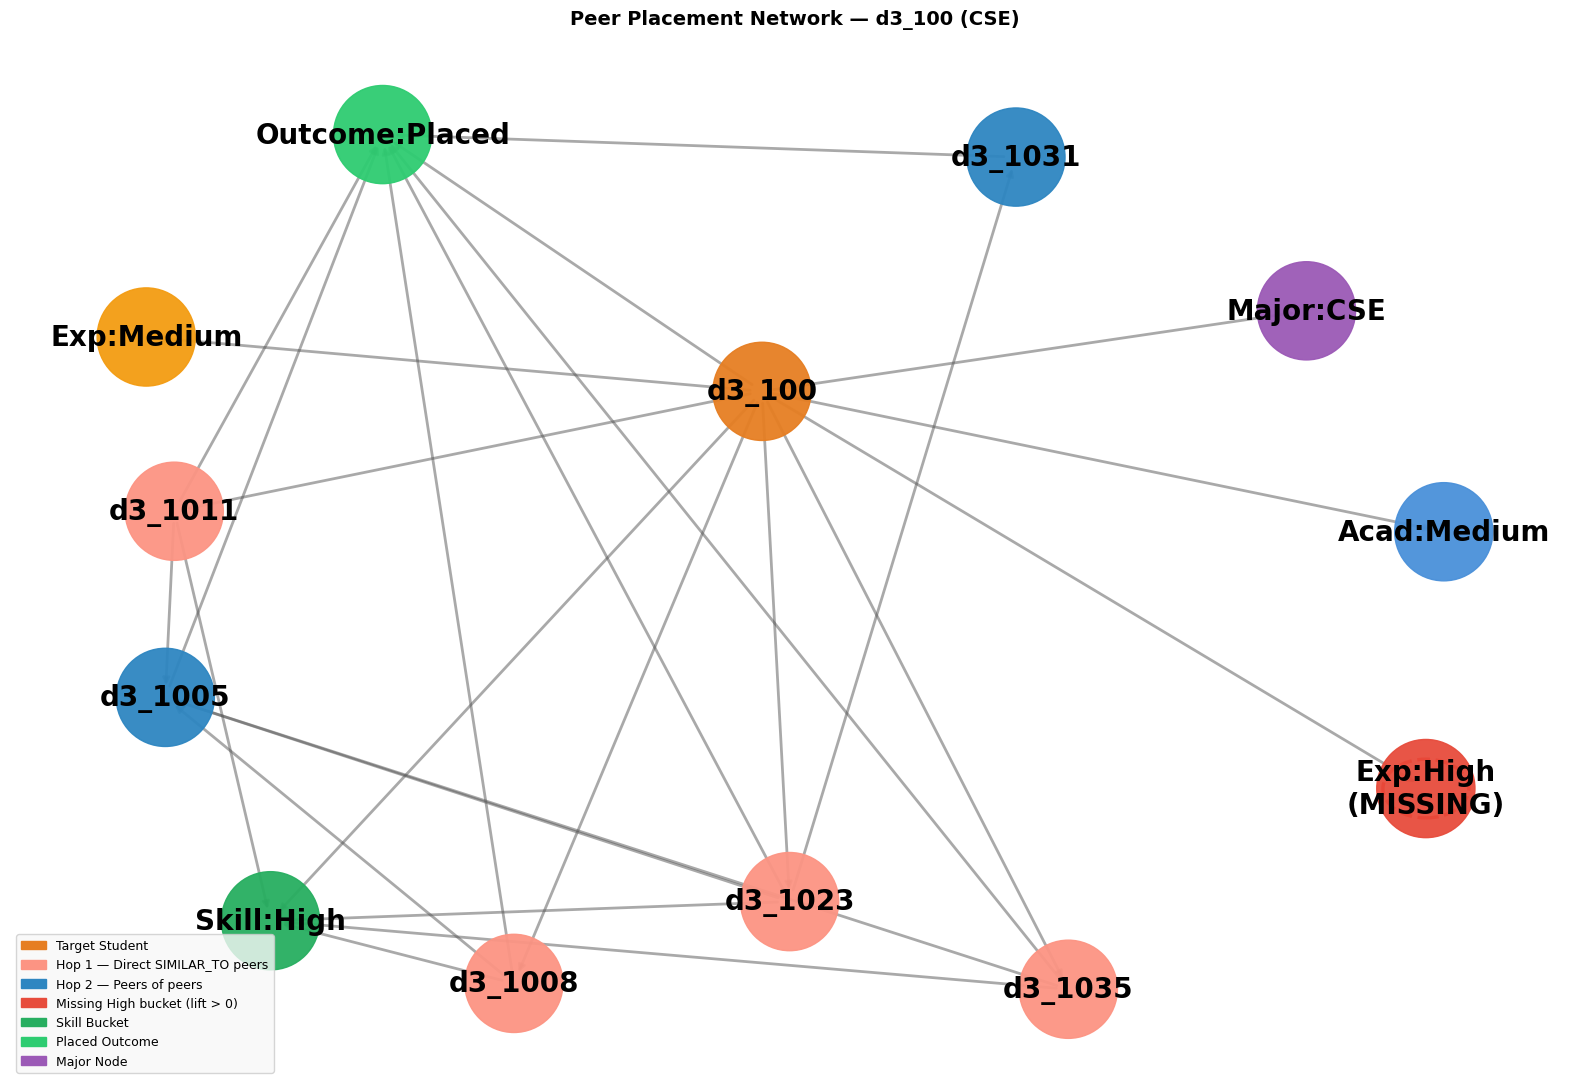


Saved: outputs/task5_3hop_d3_100_placement.png


In [39]:
print("\n=== 3-HOP (REPORT) ===")
visualize_3hop_subgraph('d3_100')